In [ ]:
import json
import numpy as np
from pathlib import Path
from common import OUTPUT_DIM_NOTES

# Define the directory containing JAMS files. The corresponding input audio files have identical names but with .wav extension. These names are deduced
# from the jams files automatically.
# jams_dirs=['/home/gerald/guitarset/annotation/rock']
jams_dirs=['/home/gerald/guitarset/annotation/rock','/home/gerald/guitarset/annotation/funk','/home/gerald/guitarset/annotation/jazz']


def load_jams_file(file_path):
    with open(file_path, 'r') as f:
        jams_data = json.load(f)
    return jams_data


def extract_guitar_annotations(jams_data):
    annotations=[]
    for annotation in jams_data['annotations']:
        if annotation['namespace']=='note_midi':
            data=annotation['data']
            for note in data:
                annotations.append({
                    'time':note['time'],
                    'duration':note['duration'],
                    'midi_note':note['value'],
                    'confidence':note['confidence']
                })
    return annotations
def create_pianoroll(annotations, sr=48000, hop_length=256,  max_note=OUTPUT_DIM_NOTES,onsets_2d=False):
    max_time=max(note['time']+note['duration'] for note in annotations)
    frame_time=1/sr
    num_frames=int(np.ceil(max_time *sr))
    num_notes=max_note
    piano_roll=np.zeros((num_frames,num_notes))
    for note in annotations:
        start_frame=int(np.floor(note['time']*sr))
        end_frame=int(np.ceil((note['time']+note['duration'])*sr))
        note_idx=int(note['midi_note'])
        if note_idx>=0 and note_idx<num_notes:
            piano_roll[start_frame:end_frame,note_idx]=1
    piano_roll=np.swapaxes(piano_roll,0,1)
    onsets=np.zeros_like(piano_roll)
    onsets[:,1:]=np.diff(piano_roll,axis=1)
    onsets=np.max(onsets,axis=0)
    onsets[np.where(onsets<0)[0]]=1
    if onsets_2d:
        onsets=np.tile(onsets,(OUTPUT_DIM_NOTES,1))
    
    for t in range(piano_roll.shape[1]):
        notes=piano_roll[range(0,OUTPUT_DIM_NOTES),t].max()
        if notes==0:
            piano_roll[OUTPUT_DIM_NOTES-1,t]=1

    return piano_roll,onsets

def load_jams_pianoroll(file_path, sr=48000, hop_length=256, max_note=OUTPUT_DIM_NOTES,onsets_2d=False):
    jams_data=load_jams_file(file_path)
    annotations=extract_guitar_annotations(jams_data)
    piano_roll=create_pianoroll(annotations, sr=sr, hop_length=hop_length, max_note=max_note,onsets_2d=onsets_2d)
    return piano_roll


Downsampling data by a factor of 1000...
(129, 1297000)
Downsampled array shape: (129, 1297)
Creating heatmap...


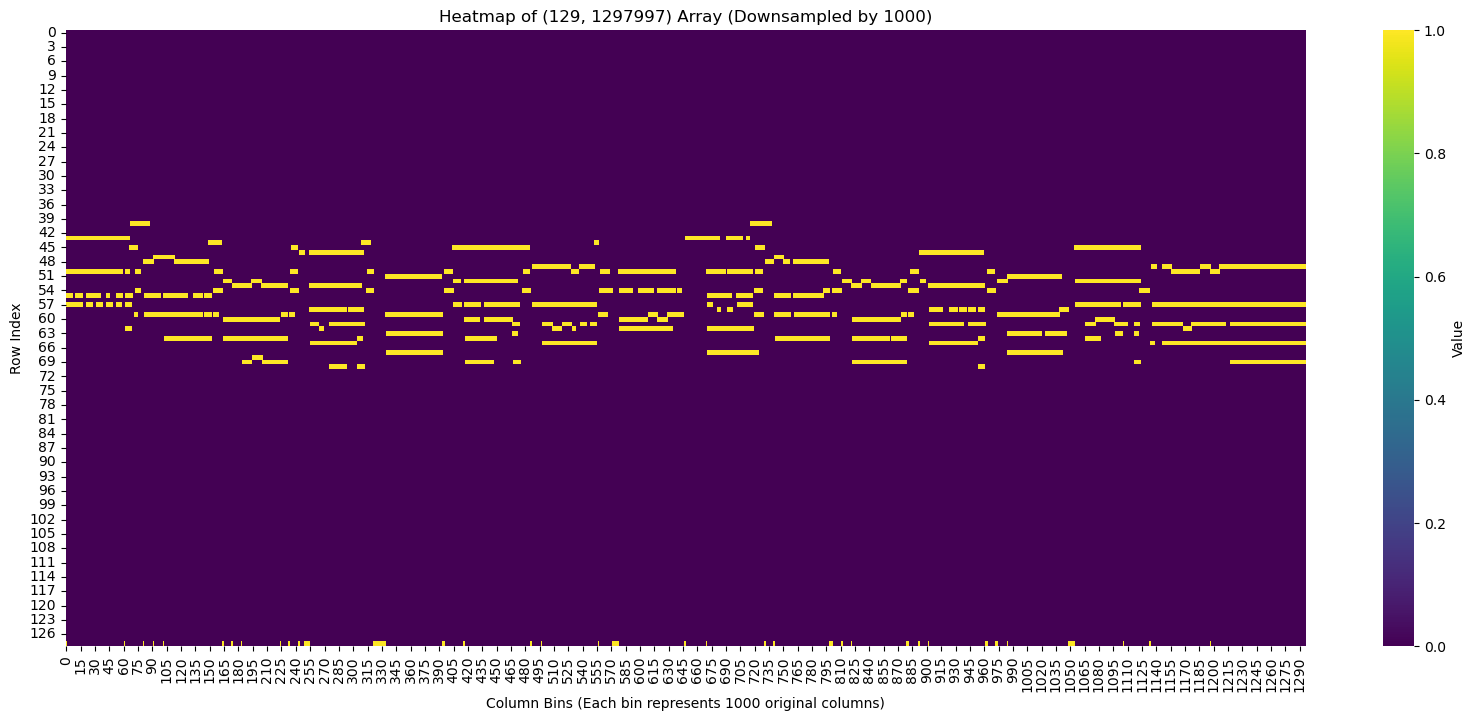

Heatmap displayed.
Onset shape: (129, 1297997)
Downsampling data by a factor of 1000...
(129, 1297000)
Downsampled array shape: (129, 1297)
Creating heatmap...


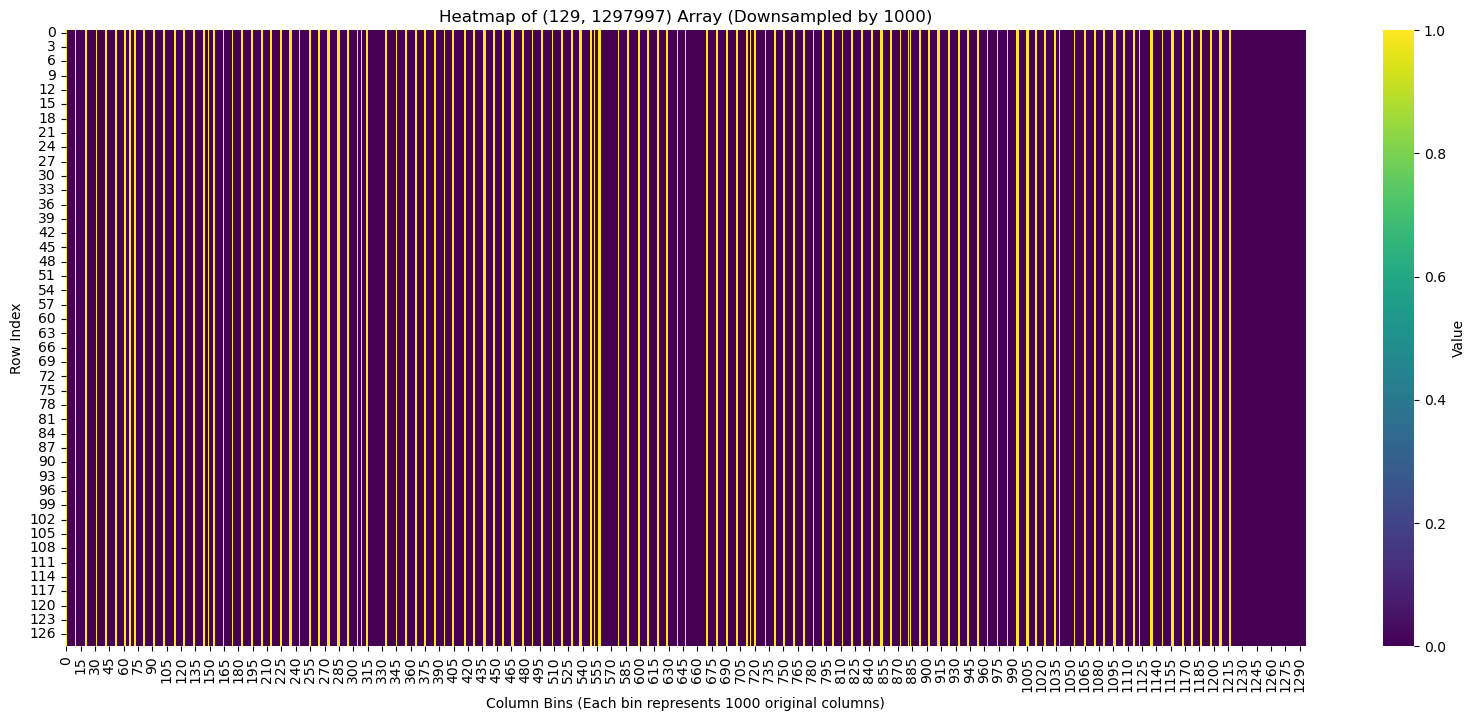

Heatmap displayed.


In [5]:
# Example of creating a piano roll from JAMS file
import matplotlib.pyplot as plt
from common import plot_heatmap

# Load and process the JAMS file
jams_file = "/home/gerald/guitarset/annotation/rock/05_Rock2-142-D_comp.jams"  # Update this path
piano_roll,onsets=load_jams_pianoroll(jams_file,onsets_2d=True)



plot_heatmap(piano_roll)
print("Onset shape:",onsets.shape)
plot_heatmap(onsets)

In [6]:
from fretboard import FretBoard
from common import frame_size,reshape_to_nn_input,reshape_to_nn_output,save_data_slices
import os
from os import path
from scipy import io
import glob 
# Files where converted with for file in *.wav; do sox -SG "$file" -r 48000 -e float -b 32 48k/"$file"; done

input_audio='/home/gerald/guitarset/audio_mono-pickup_mix/48k'
output_data_dir='data_slices/training'
def prepare_audio_midi_data(jams_file):

    # Compute the piano roll and onsets
    print(f"Processing {jams_file}")
    piano_roll,onsets=load_jams_pianoroll(jams_file)

    # We want to cut out sections around the onsets
    # Compute the positions to preserve
    onset_positions=np.where(onsets>0)[0]
    for onset in onset_positions:
        onsets[(onset-4*frame_size):onset+4*frame_size]=1

    preserve_indices=np.where(onsets==0)[0]

    #Output directory
    basename=os.path.basename(jams_file).replace('.jams','')
    dirname=os.path.join(output_data_dir,basename)
    
    #Input audio
    audio_file=path.join(input_audio,basename+'_mix.wav')
    print("Loading audio file ",audio_file)
    sample_rate,audio=io.wavfile.read(audio_file)

    # Normalize the audio
    maxaudio=np.max(np.abs(audio))
    audio=audio/maxaudio
    plt.plot(audio)
    plt.show()

    # Check the sample rate
    if sample_rate!=48000:
        print("Unexpected sample rate ",sample_rate)
        return
    
    # Match piano roll length to audio length
    lenpianorool=piano_roll.shape[1]
    desired_length=len(audio)
    if lenpianorool<desired_length:
        # Pad with zeros
        padding = desired_length - lenpianorool
        piano_roll = np.pad(piano_roll, ((0, 0), (0, padding)), mode='constant')
    elif lenpianorool>desired_length:
        # Truncate
        piano_roll = piano_roll[:, :desired_length]

    # Compute the filterbank features
    filter =FretBoard(17.5,sample_rate)
    numfilters=filter.get_num_filters()
    filterbank_out=np.zeros((numfilters,len(audio)))
    filter.process(audio,filterbank_out)

    # Prune the onset features of the filterbank output and piano roll
    filterbank_out=np.take(filterbank_out,preserve_indices,axis=1,mode='clip')

    piano_roll=np.take(piano_roll,preserve_indices,axis=1,mode='clip')
    print("Sizes after onset pruning:"+str(filterbank_out.shape)+", "+str(piano_roll.shape))
    assert filterbank_out.shape[1]==piano_roll.shape[1],"Mismatched shapes after onset pruning"

    # Visualize the pruned data
    # display(plot_heatmap(piano_roll))
    # display(plot_heatmap(filterbank_out))

    # Reshape to NN input/output format
    input_slices=reshape_to_nn_input(filterbank_out)
    
    
    
    # Create output directories
    outdir=os.path.join(dirname,'output')
    indir=os.path.join(dirname,'input')
    
    
    Path(outdir).mkdir(parents=True,exist_ok=True)
    Path(indir).mkdir(parents=True,exist_ok=True)

    # save the data slices
    print("Saving input data to ",indir)
    save_data_slices(indir,input_slices,1)
    
    print("Saving output data to ",outdir)
    output_slices=reshape_to_nn_output(piano_roll,frame_size)
    save_data_slices(outdir,output_slices,1)

from joblib import Parallel, delayed

# Flatten files as shown above
all_jams_files = [f for d in jams_dirs for f in sorted(glob.glob(os.path.join(d, '*.jams')))]

Parallel(n_jobs=5)(delayed(prepare_audio_midi_data)(f) for f in all_jams_files) 
    

# for jams_dir in jams_dirs:
#     jams_files=sorted(glob.glob(os.path.join(jams_dir, '*.jams')))

#     for jams_file in jams_files:
#         prepare_audio_midi_data(jams_file)
    


I0000 00:00:1767640210.937068 1457726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1767640210.937068 1457722 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1767640210.937067 1457725 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1767640210.937068 1457723 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

Processing /home/gerald/guitarset/annotation/funk/00_Funk2-108-Eb_comp.jamsProcessing /home/gerald/guitarset/annotation/funk/00_Funk1-114-Ab_solo.jamsProcessing /home/gerald/guitarset/annotation/funk/00_Funk1-97-C_solo.jamsProcessing /home/gerald/guitarset/annotation/funk/00_Funk1-114-Ab_comp.jams



Processing /home/gerald/guitarset/annotation/funk/00_Funk1-97-C_comp.jams
Loading audio file  /home/gerald/guitarset/audio_mono-pickup_mix/48k/00_Funk1-114-Ab_comp_mix.wav
Figure(640x480)
Loading audio file  /home/gerald/guitarset/audio_mono-pickup_mix/48k/00_Funk1-114-Ab_solo_mix.wav
Figure(640x480)
Loading audio file  /home/gerald/guitarset/audio_mono-pickup_mix/48k/00_Funk1-97-C_comp_mix.wav
Figure(640x480)
Loading audio file  /home/gerald/guitarset/audio_mono-pickup_mix/48k/00_Funk1-97-C_solo_mix.wav
Figure(640x480)
Loading audio file  /home/gerald/guitarset/audio_mono-pickup_mix/48k/00_Funk2-108-Eb_comp_mix.wav
Figure(640x480)
Sizes after onset pruning:(312, 920795), (129, 920795)
res

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,